In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [59]:
df = pd.read_csv('data.csv', encoding='latin1')

C:\Users\vivek\AppData\Local\Temp\ipykernel_19412\1625864943.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data.csv', encoding='latin1')


In [60]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
531280,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20
531281,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60
531282,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
531283,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60


In [61]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [62]:
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
531280,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20
531281,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60
531282,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
531283,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
531284,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France,14.85


# Handle file read errors and missing columns using try-except blocks. 

In [63]:
import pandas as pd

class DataLoader:
    def __init__(self, file_path):
        self.file_path = file_path
        self.data = None

    def load_data(self):
        try:
            # Try reading the CSV with UTF-8 encoding
            self.data = pd.read_csv(self.file_path, encoding='latin1')
            print("✅ File loaded successfully using latin1 encoding.")
        except FileNotFoundError:
            print("❌ Error: File not found. Please check the file path.")
        except UnicodeDecodeError:
            try:
                # Try fallback encoding if UTF-8 fails
                self.data = pd.read_csv(self.file_path, encoding='latin1')
                print("⚠️ File loaded using 'latin1' encoding due to encoding mismatch.")
            except Exception as e:
                print(f"❌ Error reading file: {e}")
        except Exception as e:
            print(f"❌ Unexpected error: {e}")

        return self.data

    def check_required_columns(self, required_cols):
        if self.data is not None:
            missing_cols = [col for col in required_cols if col not in self.data.columns]
            if missing_cols:
                print(f"⚠️ Warning: Missing columns -> {missing_cols}")
            else:
                print("✅ All required columns are present.")
        else:
            print("⚠️ Data not loaded. Cannot check columns.")

# === Usage ===
file_path = "data.csv"
required_columns = ["InvoiceNo", "StockCode", "Description", "Quantity", "InvoiceDate", 
                    "UnitPrice", "CustomerID", "Country"]

loader = DataLoader(file_path)
df = loader.load_data()
loader.check_required_columns(required_columns)

# Optional: Display first few rows if loaded
if df is not None:
    print("\nSample Data:")
    print(df.head())


✅ File loaded successfully using latin1 encoding.
✅ All required columns are present.

Sample Data:
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

           InvoiceDate  UnitPrice  CustomerID         Country  TotalAmount  
0  2010-12-01 08:26:00       2.55     17850.0  United Kingdom        15.30  
1  2010-12-01 08:26:00       3.39     17850.0  United Kingdom        20.34  
2  2010-12-01 08:26:00       2.75     17850.0  United Kingdom        22.00  
3  2010-12-01 08:26:00       3.39     17850.0  United Kingdom        20.34  
4  2010-12-01 08:26:00       3.39     17850.0  United Kingdom        20.34  


C:\Users\vivek\AppData\Local\Temp\ipykernel_19412\1399938737.py:11: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  self.data = pd.read_csv(self.file_path, encoding='latin1')


# Handle missing values in CustomerID and Description.

In [64]:
print(df['CustomerID'].isnull().sum())

133361


In [65]:
print(df['Description'].isnull().sum())

592


# Convert InvoiceDate to datetime format.

In [66]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Create a TotalAmount = Quantity * UnitPrice column. 

In [67]:
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

# Remove transactions with negative or zero quantities.

In [68]:
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')

In [69]:
df = df[df['Quantity'] > 0]

In [70]:
df.to_csv("cleaned_data.csv", index=False)

In [71]:
df['UnitPrice'] = pd.to_numeric(df['UnitPrice'], errors='coerce')

In [72]:
df = df[df['UnitPrice'] > 0]

In [73]:
df.to_csv("cleaned_data2.csv", index=False)

# Total revenue per country.

In [74]:
revenue_country = df.groupby('Country')

In [75]:
revenue_country.TotalAmount.sum().sort_values(ascending=False)

Country
United Kingdom          9025222.084
Netherlands              285446.340
EIRE                     283453.960
Germany                  228867.140
France                   209715.110
Australia                138521.310
Spain                     61577.110
Switzerland               57089.900
Belgium                   41196.340
Sweden                    38378.330
Japan                     37416.370
Norway                    36165.440
Portugal                  33747.100
Finland                   22546.080
Singapore                 21279.290
Channel Islands           20450.440
Denmark                   18955.340
Italy                     17483.240
Hong Kong                 15691.800
Cyprus                    13590.380
Austria                   10198.680
Israel                     8135.260
Poland                     7334.650
Greece                     4760.520
Unspecified                4749.790
Iceland                    4310.000
Canada                     3666.380
USA                 

# Top 10 selling products. 

In [76]:
top_product = df.groupby('Description')

In [77]:
top_product.TotalAmount.sum().sort_values(ascending=False).head(10)

Description
DOTCOM POSTAGE                        206248.77
REGENCY CAKESTAND 3 TIER              174484.74
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106292.77
PARTY BUNTING                          99504.33
JUMBO BAG RED RETROSPOT                94340.05
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
Manual                                 78112.82
POSTAGE                                78101.88
RABBIT NIGHT LIGHT                     66964.99
Name: TotalAmount, dtype: float64

# Monthly revenue trends. 

In [78]:
df['Month'] = df['InvoiceDate'].dt.month

In [79]:
monthly_revenue = df.groupby('Month')['TotalAmount'].sum().sort_index(ascending=True)

In [80]:
monthly_revenue

Month
1      691364.560
2      523631.890
3      717639.360
4      537808.621
5      770536.020
6      761739.900
7      719221.191
8      759138.380
9     1058590.172
10    1154979.300
11    1509496.330
12    1462538.820
Name: TotalAmount, dtype: float64

# Use pivot_table() for sales by country and month.

In [81]:
df['Month'] = pd.to_numeric(df['Month'], errors='coerce')

# Convert TotalAmount to numeric
df['TotalAmount'] = pd.to_numeric(df['TotalAmount'], errors='coerce')

# Remove missing or invalid data
df = df.dropna(subset=['Country', 'Month', 'TotalAmount'])

# Create Pivot Table: Total Sales by Country and Month
sales_pivot = pd.pivot_table(
    df,
    values='TotalAmount',       # What we want to analyze
    index='Country',            # Rows → Country
    columns='Month',            # Columns → Month
    aggfunc='sum',              # Aggregation → Sum of sales
    fill_value=0                # Replace NaN with 0
)

# Display the pivot table
print("📊 Sales by Country and Month:")
print(sales_pivot.head(10))

📊 Sales by Country and Month:
Month                 1         2         3        4         5         6   \
Country                                                                     
Australia        9017.71  14695.42  17223.99   771.60  13638.41  25187.77   
Austria             0.00    518.36   1708.12   680.78   1249.43      0.00   
Bahrain             0.00      0.00      0.00     0.00    548.40      0.00   
Belgium          1200.20   2181.07   3351.98  1989.48   2732.40   4274.82   
Brazil              0.00      0.00      0.00  1143.60      0.00      0.00   
Canada              0.00      0.00    140.54     0.00    534.24   1171.46   
Channel Islands   675.58   1784.71   3509.33   293.00   1207.24   2060.03   
Cyprus            547.50   4334.24    938.39     0.00      0.00   1109.32   
Czech Republic      0.00    549.26      0.00     0.00      0.00      0.00   
Denmark             0.00    399.22   3978.99     0.00    515.70   3261.15   

Month                 7         8        9   

# Identify customers with highest total spend. 

In [82]:
customer_spend = df.groupby('CustomerID')

In [83]:
customer_spend.TotalAmount.sum().sort_values(ascending=False).head(10)

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194550.79
16446.0    168472.50
14911.0    143825.06
12415.0    124914.53
14156.0    117379.63
17511.0     91062.38
16029.0     81024.84
12346.0     77183.60
Name: TotalAmount, dtype: float64

# Month, Year, Day (from InvoiceDate) 

In [84]:
df['Month'] = df['InvoiceDate'].dt.month 

In [85]:
df['Year'] = df['InvoiceDate'].dt.year

In [86]:
df['Day'] = df['InvoiceDate'].dt.day

In [87]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount,Month,Year,Day
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,12,2010,1
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12,2010,1
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,12,2010,1
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12,2010,1
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12,2010,1
...,...,...,...,...,...,...,...,...,...,...,...,...
531280,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20,12,2011,9
531281,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60,12,2011,9
531282,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,12,2011,9
531283,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,12,2011,9


# SalesCategory based on revenue ranges 

In [88]:
def CategorySales(TotalAmount):
    if TotalAmount < 500:
        return 'Low'
    elif 500 <= TotalAmount < 1000:
        return 'Medium'
    else:
        return 'High'

In [89]:
df['SalesCategory'] = df['TotalAmount'].apply(CategorySales)

In [90]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount,Month,Year,Day,SalesCategory
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,12,2010,1,Low
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12,2010,1,Low
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,12,2010,1,Low
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12,2010,1,Low
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12,2010,1,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...
531280,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20,12,2011,9,Low
531281,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60,12,2011,9,Low
531282,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,12,2011,9,Low
531283,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,12,2011,9,Low


# Calculate Cumulative Sales and Moving Average using rolling windows. 

In [91]:
df['Cumulative_Sales'] = df['TotalAmount'].cumsum()

In [92]:
df['Cumulative_Sales'].head(10)

0     15.30
1     35.64
2     57.64
3     77.98
4     98.32
5    113.62
6    139.12
7    150.22
8    161.32
9    215.40
Name: Cumulative_Sales, dtype: float64

In [93]:
df['Moving_Avg'] = df['TotalAmount'].rolling(window=2).mean()

In [94]:
df['Moving_Avg'].head(10)

0      NaN
1    17.82
2    21.17
3    21.17
4    20.34
5    17.82
6    20.40
7    18.30
8    11.10
9    32.59
Name: Moving_Avg, dtype: float64

# Monthly sales trends (line chart)

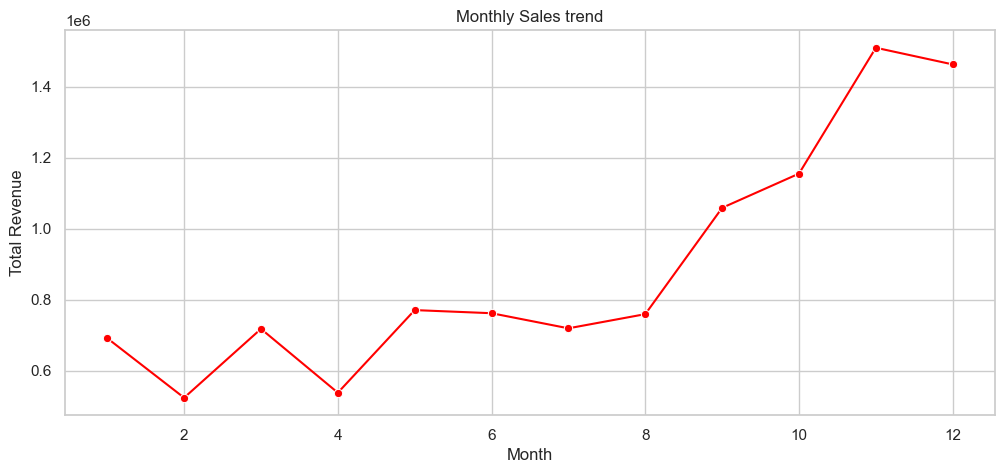

In [95]:
monthly_sales = df.groupby('Month')['TotalAmount'].sum().reset_index()

plt.figure(figsize=(12,5))
sns.lineplot(data=monthly_sales, x='Month', y='TotalAmount', marker='o', color='red')
plt.title('Monthly Sales trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.grid(True)
plt.show()

# Top-selling products (bar chart) 

C:\Users\vivek\AppData\Local\Temp\ipykernel_19412\279793957.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_product, x='TotalAmount', y='Description', palette='viridis')


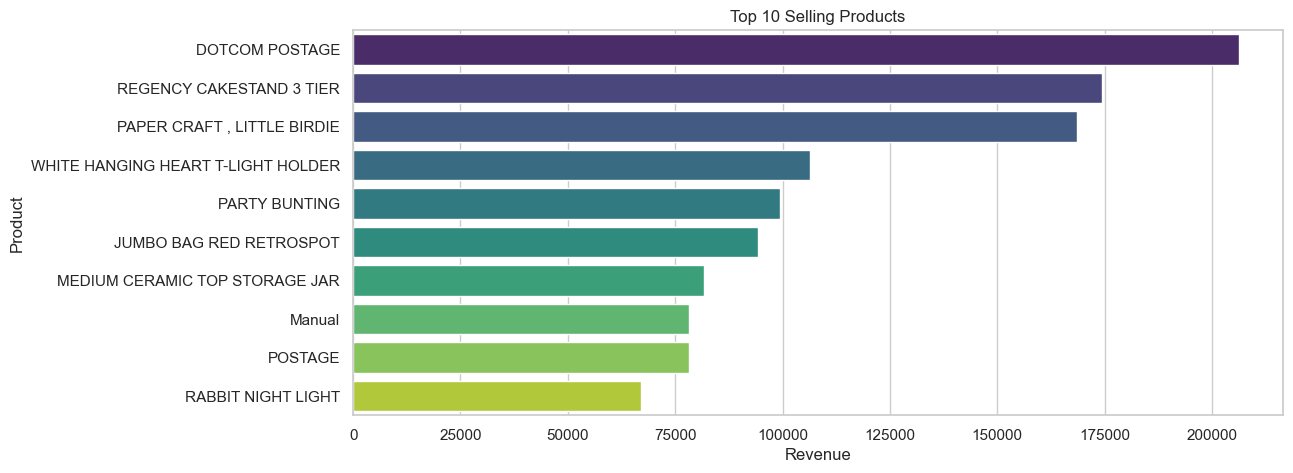

In [96]:
top_product = df.groupby('Description')['TotalAmount'].sum().nlargest(10).reset_index()

plt.figure(figsize=(12,5))
sns.barplot(data=top_product, x='TotalAmount', y='Description', palette='viridis')
plt.title('Top 10 Selling Products')
plt.xlabel('Revenue')
plt.ylabel('Product')
plt.show()

# Revenue by country (bar chart)

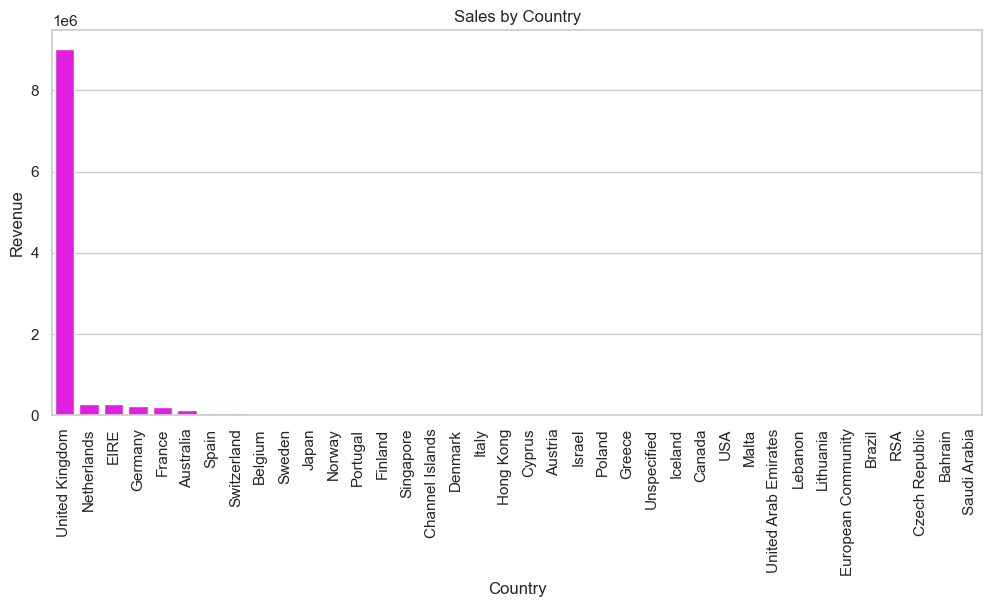

In [97]:
country_sales = df.groupby('Country')['TotalAmount'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12,5))
sns.barplot(data=country_sales, x='Country', y='TotalAmount', color='magenta')
plt.title('Sales by Country')
plt.xlabel('Country')
plt.ylabel('Revenue')
plt.xticks(rotation=90)
plt.show()

# Correlation Between Quantity and Unit Price (Scatter Plot)

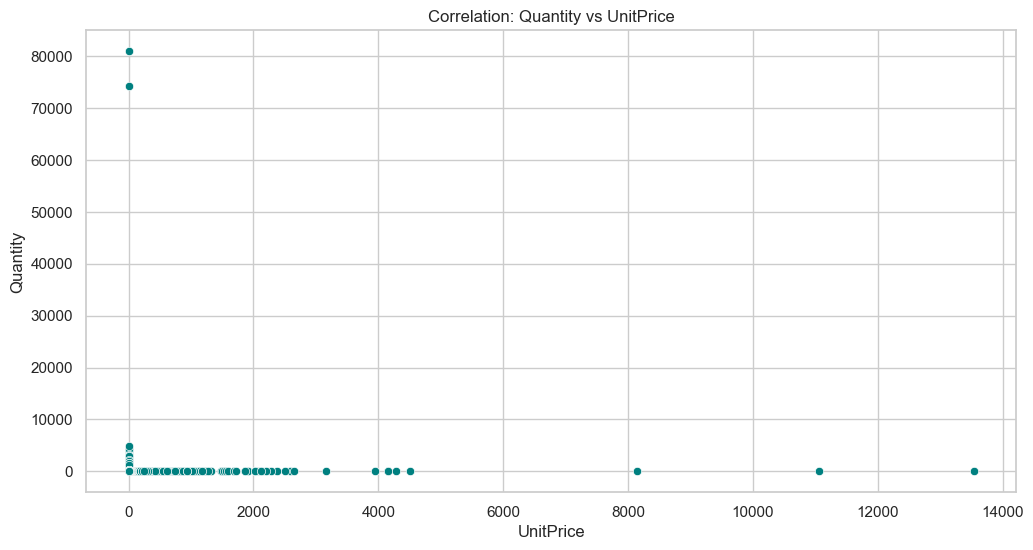

In [98]:
plt.figure(figsize=(12,6))
sns.scatterplot(data=df, x='UnitPrice', y='Quantity', color='teal')
plt.title('Correlation: Quantity vs UnitPrice')
plt.xlabel('UnitPrice')
plt.ylabel('Quantity')
plt.show()

# Heatmap Showing Monthly Sales by Region

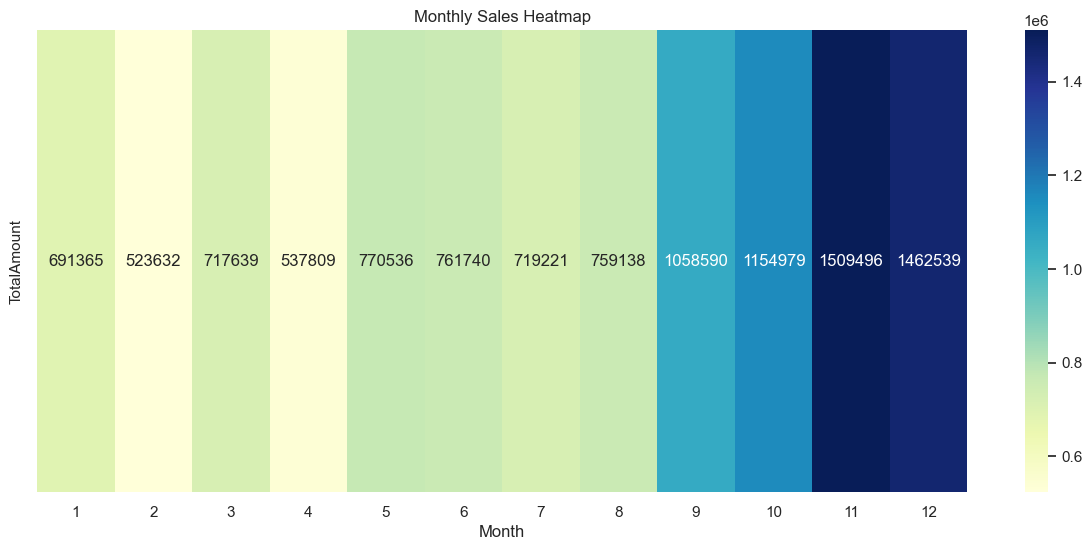

In [99]:
pivot_table = df.pivot_table(values='TotalAmount', columns='Month', aggfunc='sum', fill_value=0)

plt.figure(figsize=(15,6))
sns.heatmap(pivot_table, cmap='YlGnBu', annot=True, fmt='.0f')
plt.title('Monthly Sales Heatmap')
plt.xlabel('Month')
plt.show()

# Business Insights

In [100]:
print("="*35)
print("\tPeak Sales Month")
print("="*35)

peak_sales_month = df.groupby('Month')['TotalAmount'].sum().sort_values(ascending=False)
print(peak_sales_month)

	Peak Sales Month
Month
11    1509496.330
12    1462538.820
10    1154979.300
9     1058590.172
5      770536.020
6      761739.900
8      759138.380
7      719221.191
3      717639.360
1      691364.560
4      537808.621
2      523631.890
Name: TotalAmount, dtype: float64


In [101]:
print("="*50)
print("\t\tBest Selling Products")
print("="*50)

best_product = df.groupby('Description')['TotalAmount'].sum().sort_values(ascending=False).head(10)
print(best_product)

		Best Selling Products
Description
DOTCOM POSTAGE                        206248.77
REGENCY CAKESTAND 3 TIER              174484.74
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106292.77
PARTY BUNTING                          99504.33
JUMBO BAG RED RETROSPOT                94340.05
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
Manual                                 78112.82
POSTAGE                                78101.88
RABBIT NIGHT LIGHT                     66964.99
Name: TotalAmount, dtype: float64


In [102]:
print("="*50)
print('\t\tTop Countries by Sales')
print("="*50)

top_sales_country = df.groupby('Country')['TotalAmount'].sum().sort_values(ascending=False).head(10)
print(top_sales_country)

		Top Countries by Sales
Country
United Kingdom    9025222.084
Netherlands        285446.340
EIRE               283453.960
Germany            228867.140
France             209715.110
Australia          138521.310
Spain               61577.110
Switzerland         57089.900
Belgium             41196.340
Sweden              38378.330
Name: TotalAmount, dtype: float64


In [103]:
print("="*45)
print('\tCustomer Behaviour Insights')
print("="*45)

top_customer = df.groupby('CustomerID')['TotalAmount'].sum().sort_values(ascending=False).head(10)
print(top_customer)

	Customer Behaviour Insights
CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194550.79
16446.0    168472.50
14911.0    143825.06
12415.0    124914.53
14156.0    117379.63
17511.0     91062.38
16029.0     81024.84
12346.0     77183.60
Name: TotalAmount, dtype: float64


C:\Users\vivek\AppData\Local\Temp\ipykernel_19412\2345655591.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10.index.astype(str), y=top10.values, palette='viridis')


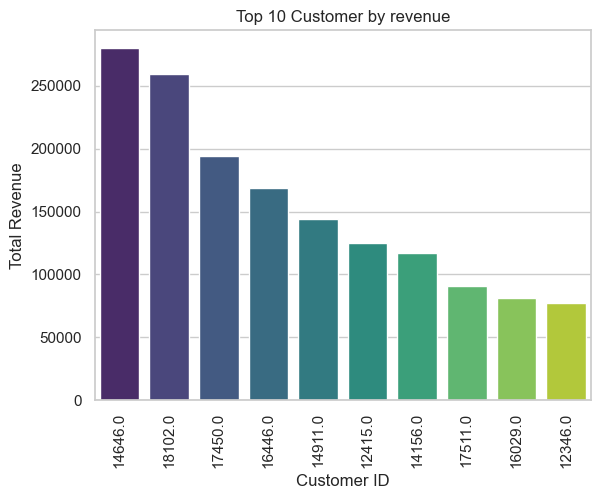

In [104]:
top10 = top_customer.head(10)
sns.barplot(x=top10.index.astype(str), y=top10.values, palette='viridis')
plt.xlabel("Customer ID")
plt.ylabel("Total Revenue")
plt.xticks(rotation=90)
plt.title("Top 10 Customer by revenue")
plt.show()

In [105]:
print("="*40)
print("Patterns in revenue growth or decline ")
print("="*40)

monthly_revenue = df.groupby(['Year', 'Month'])['TotalAmount'].sum().reset_index()

print(monthly_revenue.head())

Patterns in revenue growth or decline 
   Year  Month  TotalAmount
0  2010     12   823746.140
1  2011      1   691364.560
2  2011      2   523631.890
3  2011      3   717639.360
4  2011      4   537808.621


In [106]:
monthly_revenue['Date'] = pd.to_datetime(monthly_revenue['Year'].astype(str) + '-' + monthly_revenue['Month'].astype(str) + '-01')
monthly_revenue = monthly_revenue.sort_values('Date')
monthly_revenue['Growth %'] = monthly_revenue['TotalAmount'].pct_change() * 100
print(monthly_revenue[['Month', 'TotalAmount', 'Growth %']])

    Month  TotalAmount   Growth %
0      12   823746.140        NaN
1       1   691364.560 -16.070677
2       2   523631.890 -24.261103
3       3   717639.360  37.050354
4       4   537808.621 -25.058650
5       5   770536.020  43.273274
6       6   761739.900  -1.141559
7       7   719221.191  -5.581788
8       8   759138.380   5.550057
9       9  1058590.172  39.446272
10     10  1154979.300   9.105424
11     11  1509496.330  30.694665
12     12   638792.680 -57.681733


# Expected Python Concepts to Demonstrate 

In [50]:
"""
data_analysis_project.py

Demonstrates:
- OOP: DataManager, Cleaner, Analyzer, Visualizer
- Exception handling for file I/O and dtype issues
- NumPy usage for numeric transforms
- Pandas for grouping, pivoting, filtering, merging, cleaning
- Seaborn / Matplotlib visualizations (heatmap, bar, line)
- Functions for modular reusable blocks
- File saving (CSV and PNG)

Usage:
    python data_analysis_project.py
"""

import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Helper functions (functional modularity) ---
def safe_read_csv(path, encodings=("utf-8", "latin1")):
    """Try reading CSV with several encodings, raise informative errors."""
    for enc in encodings:
        try:
            return pd.read_csv(path, encoding=enc)
        except FileNotFoundError:
            raise
        except UnicodeDecodeError:
            continue
    # final attempt without encoding arg
    return pd.read_csv(path)

def ensure_numeric(series, col_name, coerce=True):
    """Convert a Series to numeric, optionally coercing errors to NaN."""
    if coerce:
        return pd.to_numeric(series, errors='coerce')
    return pd.to_numeric(series)

def save_csv_safe(df, path):
    """Save dataframe and print status; create parent dirs if needed."""
    os.makedirs(os.path.dirname(path) or ".", exist_ok=True)
    df.to_csv(path, index=False)
    print(f"💾 Saved CSV: {path}")

# --- OOP classes ---
class DataManager:
    """Load and provide access to raw data with error handling."""
    def __init__(self, file_path):
        self.file_path = file_path
        self.df = None

    def load(self):
        try:
            self.df = safe_read_csv(self.file_path)
            print("✅ Loaded data (first 3 rows):")
            print(self.df.head(3))
        except FileNotFoundError:
            print(f"❌ File not found: {self.file_path}")
            raise
        except Exception as e:
            print(f"❌ Unexpected error when reading file: {e}")
            raise
        return self.df

class Cleaner:
    """Clean the DataFrame: dtypes, missing values, remove invalid transactions."""
    def __init__(self, df):
        self.df = df.copy()

    def ensure_columns(self, required_cols):
        missing = [c for c in required_cols if c not in self.df.columns]
        if missing:
            raise KeyError(f"Missing required columns: {missing}")
        print("✅ Required columns present.")

    def convert_types(self):
        # Convert common numeric fields safely
        for col in ['Quantity', 'UnitPrice', 'TotalAmount', 'Month']:
            if col in self.df.columns:
                self.df[col] = ensure_numeric(self.df[col], col, coerce=True)
        # CustomerID often is numeric but can be read as float due to NaNs; keep as string for grouping keys
        if 'CustomerID' in self.df.columns:
            # Keep as string to preserve leading zeros if any, but drop rows with NaN
            self.df['CustomerID'] = self.df['CustomerID'].astype('Int64').astype(str).replace('<NA>', np.nan)
        # InvoiceDate -> datetime
        if 'InvoiceDate' in self.df.columns:
            try:
                self.df['InvoiceDate'] = pd.to_datetime(self.df['InvoiceDate'], errors='coerce')
            except Exception:
                self.df['InvoiceDate'] = pd.to_datetime(self.df['InvoiceDate'], dayfirst=True, errors='coerce')
        print("✅ Converted data types where possible.")

    def remove_invalid_quantities(self):
        """Remove rows where Quantity is <= 0 or NaN."""
        if 'Quantity' not in self.df.columns:
            print("⚠️ 'Quantity' column not present; skipping quantity filter.")
            return
        before = len(self.df)
        # Treat NaN as invalid as well; keep only strictly positive numbers
        self.df = self.df[self.df['Quantity'] > 0].dropna(subset=['Quantity'])
        after = len(self.df)
        print(f"✅ Removed {before - after} rows with Quantity <= 0 or NaN.")

    def fill_missing_totals(self):
        """If TotalAmount missing but Quantity & UnitPrice exist, compute it."""
        if set(['TotalAmount', 'Quantity', 'UnitPrice']).issubset(self.df.columns):
            mask = self.df['TotalAmount'].isna() & self.df['Quantity'].notna() & self.df['UnitPrice'].notna()
            count = mask.sum()
            self.df.loc[mask, 'TotalAmount'] = self.df.loc[mask, 'Quantity'] * self.df.loc[mask, 'UnitPrice']
            print(f"✅ Computed {count} missing TotalAmount values from Quantity * UnitPrice.")

    def clean_stockcode(self):
        """Example cleaning: remove rows whose Stock Code is 'BANK CHARGE' or 'DO'/'PAD' or blanks."""
        if 'Stock Code' in self.df.columns:
            # Normalize and filter
            sc = self.df['StockCode'].astype(str).str.strip().str.upper()
            mask_bad = sc.isin(['BANK CHARGE', 'DO', 'PAD']) | (sc == '') | sc.isna()
            removed = mask_bad.sum()
            self.df = self.df[~mask_bad]
            print(f"✅ Removed {removed} rows with unwanted Stock Code values.")

    def run_all(self, required_cols=None):
        try:
            if required_cols:
                self.ensure_columns(required_cols)
        except KeyError as e:
            print(f"❌ {e}")
            raise
        self.convert_types()
        self.remove_invalid_quantities()
        self.fill_missing_totals()
        self.clean_stockcode()
        # Final drop rows missing essential fields
        essential = ['CustomerID', 'TotalAmount', 'Month']
        present_essentials = [c for c in essential if c in self.df.columns]
        self.df = self.df.dropna(subset=present_essentials)
        print("✅ Cleaning complete. Rows remaining:", len(self.df))
        return self.df

class Analyzer:
    """Perform grouping, pivoting and statistical computations."""
    def __init__(self, df):
        self.df = df.copy()

    def monthly_revenue(self):
        """Return Series of monthly total revenue sorted by calendar month."""
        if 'Month' not in self.df.columns or 'TotalAmount' not in self.df.columns:
            raise KeyError("Month or TotalAmount missing for monthly revenue.")
        # If Month is numeric (1-12) sort by index; else convert categorical using month names if present
        monthly = self.df.groupby('Month')['TotalAmount'].sum()
        # If index is numeric like 1..12 -> sort_index; else try to order by month names
        if np.issubdtype(monthly.index.dtype, np.number):
            monthly = monthly.sort_index()
        else:
            # attempt ordering if month names present
            month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']
            cat_index = pd.CategoricalIndex(monthly.index, categories=month_order, ordered=True)
            monthly.index = cat_index
            monthly = monthly.sort_index()
        return monthly

    def sales_by_country_month_pivot(self):
        """Return pivot table (DataFrame) with countries as rows and months as columns."""
        if not set(['Country', 'Month', 'TotalAmount']).issubset(self.df.columns):
            raise KeyError("Country, Month or TotalAmount column missing.")
        pivot = pd.pivot_table(
            self.df,
            values='TotalAmount',
            index='Country',
            columns='Month',
            aggfunc='sum',
            fill_value=0
        )
        # ensure numeric column ordering if months are numbers
        try:
            pivot.columns = pivot.columns.astype(int)
            pivot = pivot.reindex(sorted(pivot.columns), axis=1)
        except Exception:
            pass
        return pivot

    def top_customers(self, n=10):
        """Return DataFrame of top n customers by total spend."""
        if 'CustomerID' not in self.df.columns or 'TotalAmount' not in self.df.columns:
            raise KeyError("CustomerID or TotalAmount missing.")
        cust = self.df.groupby('CustomerID')['TotalAmount'].sum().sort_values(ascending=False).head(n)
        return cust.reset_index().rename(columns={'TotalAmount': 'TotalSpend'})

class Visualizer:
    """Create and save plots: monthly trend, top customers bar, heatmap of pivot."""
    def __init__(self, out_dir="outputs"):
        self.out_dir = out_dir
        os.makedirs(self.out_dir, exist_ok=True)
        sns.set(style="whitegrid")

    def plot_monthly_revenue(self, monthly_series, fname="monthly_revenue.png"):
        plt.figure(figsize=(10, 5))
        # if index are numbers or categorical, pandas plotting works
        monthly_series = monthly_series.sort_index()
        ax = monthly_series.plot(marker='o')
        ax.set_title("Monthly Revenue")
        ax.set_xlabel("Month")
        ax.set_ylabel("Total Revenue")
        plt.tight_layout()
        out = os.path.join(self.out_dir, fname)
        plt.savefig(out)
        plt.close()
        print(f"🖼️ Saved monthly revenue plot: {out}")

    def plot_top_customers(self, top_customers_df, fname="top_customers.png"):
        plt.figure(figsize=(10, 6))
        ax = sns.barplot(data=top_customers_df, x='TotalSpend', y='CustomerID')
        ax.set_title("Top Customers by Total Spend")
        ax.set_xlabel("Total Spend")
        ax.set_ylabel("Customer ID")
        plt.tight_layout()
        out = os.path.join(self.out_dir, fname)
        plt.savefig(out)
        plt.close()
        print(f"🖼️ Saved top customers plot: {out}")

    def plot_heatmap_pivot(self, pivot_df, fname="sales_heatmap.png"):
        plt.figure(figsize=(12, max(6, pivot_df.shape[0]/3)))
        ax = sns.heatmap(pivot_df, annot=False, fmt=".0f", linewidths=.5, cmap="YlGnBu")
        ax.set_title("Sales by Country (rows) and Month (columns)")
        plt.tight_layout()
        out = os.path.join(self.out_dir, fname)
        plt.savefig(out)
        plt.close()
        print(f"🖼️ Saved heatmap: {out}")

# --- Main script demonstrating all pieces ---
def main():
    FILE_PATH = "data.csv"
    # Required columns we will use in the demo
    required_cols = ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
                     'UnitPrice', 'CustomerID', 'Country', 'TotalAmount']

    # 1) Load
    dm = DataManager(FILE_PATH)
    try:
        df = dm.load()
    except FileNotFoundError:
        print("Exiting: input file not found.")
        sys.exit(1)
    except Exception as e:
        print("Exiting due to read error:", e)
        sys.exit(1)

    # 2) Clean
    cleaner = Cleaner(df)
    try:
        cleaned = cleaner.run_all(required_cols=required_cols)
    except KeyError as e:
        # If required columns missing, try to proceed with available columns instead of failing
        print("Warning - required columns missing for strict cleaning:", e)
        # attempt best-effort cleaning without enforcing required columns
        cleaned = Cleaner(df).run_all(required_cols=None)
    except Exception as e:
        print("Unexpected error during cleaning:", e)
        sys.exit(1)

    # Save cleaned data
    save_csv_safe(cleaned, "cleaned_data.csv")

    # 3) Analyze
    analyzer = Analyzer(cleaned)
    try:
        monthly = analyzer.monthly_revenue()
        print("\n📈 Monthly Revenue (sample):")
        print(monthly.head(12))
    except Exception as e:
        print("Error computing monthly revenue:", e)
        monthly = pd.Series(dtype=float)

    try:
        pivot = analyzer.sales_by_country_month_pivot()
        print("\n📊 Pivot (countries x months) shape:", pivot.shape)
        save_csv_safe(pivot.reset_index(), "sales_by_country_month.csv")
    except Exception as e:
        print("Error building pivot table:", e)
        pivot = pd.DataFrame()

    try:
        top_customers = analyzer.top_customers(n=10)
        print("\n💰 Top customers:")
        print(top_customers)
        save_csv_safe(top_customers, "top_customers.csv")
    except Exception as e:
        print("Error computing top customers:", e)
        top_customers = pd.DataFrame()

    # 4) Visualize
    viz = Visualizer(out_dir="outputs")
    if not monthly.empty:
        viz.plot_monthly_revenue(monthly)
    if not top_customers.empty:
        viz.plot_top_customers(top_customers)
    if not pivot.empty:
        # for heatmap, ensure numeric columns and reasonable shape
        viz.plot_heatmap_pivot(pivot)

    # 5) NumPy demonstration: compute percentiles of customer spend
    try:
        spend_array = top_customers['TotalSpend'].to_numpy()
        if spend_array.size > 0:
            percentiles = np.percentile(spend_array, [25, 50, 75])
            print("\n🔢 Top customers spend percentiles (25th, 50th, 75th):", percentiles)
    except Exception as e:
        print("NumPy computation failed:", e)

    print("\n✅ Script finished. Check cleaned_data.csv, outputs/ and CSV results.")

if __name__ == "__main__":
    main()


C:\Users\vivek\AppData\Local\Temp\ipykernel_19412\1935089764.py:29: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(path, encoding=enc)


✅ Loaded data (first 3 rows):
  InvoiceNo StockCode                         Description  Quantity  \
0    536365    85123A  WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                 WHITE METAL LANTERN         6   
2    536365    84406B      CREAM CUPID HEARTS COAT HANGER         8   

           InvoiceDate  UnitPrice  CustomerID         Country  TotalAmount  
0  2010-12-01 08:26:00       2.55     17850.0  United Kingdom        15.30  
1  2010-12-01 08:26:00       3.39     17850.0  United Kingdom        20.34  
2  2010-12-01 08:26:00       2.75     17850.0  United Kingdom        22.00  
✅ Required columns present.
✅ Converted data types where possible.
✅ Removed 0 rows with Quantity <= 0 or NaN.
✅ Computed 0 missing TotalAmount values from Quantity * UnitPrice.
✅ Cleaning complete. Rows remaining: 397924
💾 Saved CSV: cleaned_data.csv
Error computing monthly revenue: 'Month or TotalAmount missing for monthly revenue.'
Error building pivot table: 'Country, Mo

In [51]:
class SalesDataLoader: 
    def __init__(self, file_path: str): 
        self.file_path = file_path 
 
    def load_data(self): 
        try: 
            df = pd.read_csv(self.file_path, encoding='unicode_escape') 
            df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate']) 
            df.dropna(subset=['CustomerID'], inplace=True) 
            df['TotalAmount'] = df['Quantity'] * df['UnitPrice'] 
            print(f"Data Loaded Successfully. Shape: {df.shape}") 
            return df 
        except FileNotFoundError: 
            print("File not found. Please check the path.") 
        except Exception as e: 
            print(f"Error loading data: {e}")

In [52]:
# Replace this path with your file location
file_path = "cleaned_data2.csv"

# Create an object
loader = SalesDataLoader(file_path)

# Call the load_data() method
df = loader.load_data()

# (Optional) Display more rows if needed
if df is not None:
    print("\n📊 First 5 records:")
    print(df.head())

    print("\n📈 Columns available:")
    print(df.columns.tolist())

C:\Users\vivek\AppData\Local\Temp\ipykernel_19412\300487398.py:7: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(self.file_path, encoding='unicode_escape')


Data Loaded Successfully. Shape: (397884, 9)

📊 First 5 records:
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  TotalAmount  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom        15.30  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom        20.34  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom        22.00  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom        20.34  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom        20.34  

📈 Columns available:
['InvoiceNo', 'StockCode

In [53]:
"""
sales_project_demo.py

Demonstrates project learning objectives:
- OOP for analysis workflows
- Pandas & NumPy for cleaning, transformation, aggregation
- Seaborn & Matplotlib visualizations
- Exception handling for robust code
- Business insights: monthly revenue, top customers, top products, country sales

Usage:
    python sales_project_demo.py
"""

import os
import sys
from typing import Optional
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------
# Utility functions
# -------------------------
def safe_read_csv(path: str, encodings=("utf-8", "latin1", "unicode_escape")) -> pd.DataFrame:
    """Try several encodings, raise FileNotFoundError if file missing."""
    if not os.path.exists(path):
        raise FileNotFoundError(f"File not found: {path}")
    last_err = None
    for enc in encodings:
        try:
            return pd.read_csv(path, encoding=enc)
        except Exception as e:
            last_err = e
            continue
    # final attempt without specifying encoding
    try:
        return pd.read_csv(path)
    except Exception:
        raise last_err or Exception("Failed to read CSV with supported encodings")

def ensure_numeric(series: pd.Series) -> pd.Series:
    return pd.to_numeric(series, errors="coerce")

def save_df(df: pd.DataFrame, path: str) -> None:
    os.makedirs(os.path.dirname(path) or ".", exist_ok=True)
    df.to_csv(path, index=False)
    print(f"Saved: {path}")

# -------------------------
# OOP components
# -------------------------
class DataLoader:
    """Loads CSV and performs minimal parsing."""
    def __init__(self, file_path: str):
        self.file_path = file_path

    def load(self) -> pd.DataFrame:
        try:
            df = safe_read_csv(self.file_path)
            print(f"Loaded file: {self.file_path} (shape={df.shape})")
            # try to parse InvoiceDate if present
            if 'InvoiceDate' in df.columns:
                df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')
            return df
        except FileNotFoundError as e:
            print(f"ERROR: {e}")
            raise
        except Exception as e:
            print(f"Unexpected error while loading: {e}")
            raise

class Cleaner:
    """Cleaning: types, missing values, invalid transactions, derived columns."""
    def __init__(self, df: pd.DataFrame):
        self.df = df.copy()

    def standardize_column_names(self):
        # optional: strip and unify column names
        self.df.columns = [c.strip() for c in self.df.columns]

    def to_numeric_fields(self, cols):
        for c in cols:
            if c in self.df.columns:
                self.df[c] = ensure_numeric(self.df[c])

    def compute_total_amount(self):
        if 'TotalAmount' not in self.df.columns:
            if set(['Quantity', 'UnitPrice']).issubset(self.df.columns):
                self.df['TotalAmount'] = self.df['Quantity'] * self.df['UnitPrice']

    def remove_invalid_quantities(self):
        if 'Quantity' in self.df.columns:
            before = len(self.df)
            # keep only strictly positive quantities; treat NaN as invalid
            self.df = self.df[self.df['Quantity'] > 0].dropna(subset=['Quantity'])
            print(f"Removed {before - len(self.df)} rows with Quantity <= 0 or NaN")

    def drop_missing_customers(self):
        if 'CustomerID' in self.df.columns:
            before = len(self.df)
            self.df.dropna(subset=['CustomerID'], inplace=True)
            print(f"Dropped {before - len(self.df)} rows missing CustomerID")

    def clean_stock_code_bad(self):
        # remove rows with bank charges, DO, PAD or blanks if Stock Code exists
        col = 'Stock Code'
        if col in self.df.columns:
            sc = self.df[col].astype(str).str.strip().str.upper()
            mask_bad = sc.isin(['BANK CHARGE', 'DO', 'PAD']) | (sc == '') | sc.isna()
            removed = mask_bad.sum()
            self.df = self.df[~mask_bad]
            print(f"Removed {removed} bad Stock Code rows")

    def extract_month_year(self):
        # derive Month (1-12) and Year from InvoiceDate if missing
        if 'InvoiceDate' in self.df.columns:
            self.df['Month'] = self.df['InvoiceDate'].dt.month
            self.df['Year'] = self.df['InvoiceDate'].dt.year

    def run_all(self):
        self.standardize_column_names()
        # Convert common numeric fields
        self.to_numeric_fields(['Quantity', 'UnitPrice', 'TotalAmount', 'Month'])
        self.compute_total_amount()
        self.remove_invalid_quantities()
        self.drop_missing_customers()
        self.clean_stock_code_bad()
        self.extract_month_year()
        # final: drop rows missing critical fields
        critical = [c for c in ['TotalAmount', 'CustomerID', 'Month'] if c in self.df.columns]
        if critical:
            before = len(self.df)
            self.df = self.df.dropna(subset=critical)
            print(f"Dropped {before - len(self.df)} rows missing critical fields: {critical}")
        print(f"Cleaning complete. Remaining rows: {len(self.df)}")
        return self.df

class Analyzer:
    """Compute business insights: monthly revenue, top customers, top products, country sales."""
    def __init__(self, df: pd.DataFrame):
        self.df = df.copy()

    def monthly_revenue(self) -> pd.Series:
        if 'Month' not in self.df.columns or 'TotalAmount' not in self.df.columns:
            raise KeyError("Month or TotalAmount missing")
        monthly = self.df.groupby('Month')['TotalAmount'].sum()
        # ensure sorted by calendar month numeric order if possible
        try:
            monthly.index = monthly.index.astype(int)
            monthly = monthly.sort_index()
        except Exception:
            monthly = monthly.sort_index()
        return monthly

    def top_customers(self, n=10) -> pd.DataFrame:
        if 'CustomerID' not in self.df.columns or 'TotalAmount' not in self.df.columns:
            raise KeyError("CustomerID or TotalAmount missing")
        top = (self.df.groupby('CustomerID')['TotalAmount']
                 .sum()
                 .sort_values(ascending=False)
                 .head(n)
                 .reset_index()
                 .rename(columns={'TotalAmount': 'TotalSpend'}))
        return top

    def top_products(self, n=10) -> pd.DataFrame:
        # choose 'Stock Code' or 'Description' whichever present
        key = 'Stock Code' if 'Stock Code' in self.df.columns else 'Description'
        if key not in self.df.columns:
            raise KeyError("No product identifier column present")
        top = (self.df.groupby(key)['TotalAmount']
                 .sum()
                 .sort_values(ascending=False)
                 .head(n)
                 .reset_index()
                 .rename(columns={'TotalAmount': 'Sales'}))
        return top

    def sales_by_country_month(self) -> pd.DataFrame:
        if not set(['Country', 'Month', 'TotalAmount']).issubset(self.df.columns):
            raise KeyError("Country, Month, or TotalAmount missing")
        pivot = pd.pivot_table(
            self.df,
            values='TotalAmount',
            index='Country',
            columns='Month',
            aggfunc='sum',
            fill_value=0
        )
        # try to reorder numeric month columns
        try:
            pivot.columns = pivot.columns.astype(int)
            pivot = pivot.reindex(sorted(pivot.columns), axis=1)
        except Exception:
            pass
        return pivot

class Visualizer:
    """Create plots and save them to disk."""
    def __init__(self, out_dir="outputs"):
        self.out_dir = out_dir
        os.makedirs(self.out_dir, exist_ok=True)
        sns.set(style="whitegrid")

    def plot_monthly_revenue(self, monthly: pd.Series, fname="monthly_revenue.png"):
        if monthly.empty:
            print("No monthly data to plot")
            return
        plt.figure(figsize=(10,5))
        monthly.plot(marker='o')
        plt.title("Monthly Revenue")
        plt.xlabel("Month")
        plt.ylabel("TotalAmount")
        plt.tight_layout()
        path = os.path.join(self.out_dir, fname)
        plt.savefig(path)
        plt.close()
        print(f"Saved plot: {path}")

    def plot_top_customers(self, top_customers: pd.DataFrame, fname="top_customers.png"):
        if top_customers.empty:
            print("No top customers to plot")
            return
        plt.figure(figsize=(8,6))
        sns.barplot(x='TotalSpend', y='CustomerID', data=top_customers)
        plt.title("Top Customers by Total Spend")
        plt.tight_layout()
        path = os.path.join(self.out_dir, fname)
        plt.savefig(path)
        plt.close()
        print(f"Saved plot: {path}")

    def plot_heatmap(self, pivot_df: pd.DataFrame, fname="sales_heatmap.png"):
        if pivot_df.empty:
            print("No pivot data to plot")
            return
        plt.figure(figsize=(12, max(6, pivot_df.shape[0]/4)))
        sns.heatmap(pivot_df, cmap="YlGnBu", linewidths=0.4)
        plt.title("Sales by Country and Month")
        plt.tight_layout()
        path = os.path.join(self.out_dir, fname)
        plt.savefig(path)
        plt.close()
        print(f"Saved heatmap: {path}")

# -------------------------
# Main demonstration flow
# -------------------------
def main(file_path="data.csv"):
    # 1) Load
    try:
        loader = DataLoader(file_path)
        df_raw = loader.load()
    except FileNotFoundError:
        print("Exiting: data file not found.")
        sys.exit(1)
    except Exception as e:
        print(f"Exiting due to load error: {e}")
        sys.exit(1)

    # 2) Clean
    cleaner = Cleaner(df_raw)
    try:
        df_clean = cleaner.run_all()
    except Exception as e:
        print(f"Error during cleaning: {e}")
        sys.exit(1)

    # Save cleaned dataset
    save_df(df_clean, os.path.join("outputs", "cleaned_data.csv"))

    # 3) Analyze
    analyzer = Analyzer(df_clean)
    insights = {}

    # monthly revenue
    try:
        monthly = analyzer.monthly_revenue()
        insights['monthly_revenue'] = monthly
        print("\nMonthly Revenue (sample):")
        print(monthly.head(12))
    except Exception as e:
        print(f"Could not compute monthly revenue: {e}")
        monthly = pd.Series(dtype=float)

    # top customers
    try:
        top_customers = analyzer.top_customers(n=10)
        insights['top_customers'] = top_customers
        print("\nTop Customers:")
        print(top_customers)
        save_df(top_customers, os.path.join("outputs", "top_customers.csv"))
    except Exception as e:
        print(f"Could not compute top customers: {e}")
        top_customers = pd.DataFrame()

    # top products
    try:
        top_products = analyzer.top_products(n=10)
        insights['top_products'] = top_products
        print("\nTop Products:")
        print(top_products)
        save_df(top_products, os.path.join("outputs", "top_products.csv"))
    except Exception as e:
        print(f"Could not compute top products: {e}")
        top_products = pd.DataFrame()

    # sales pivot (country x month)
    try:
        pivot = analyzer.sales_by_country_month()
        insights['sales_pivot'] = pivot
        print("\nSales pivot shape:", pivot.shape)
        save_df(pivot.reset_index(), os.path.join("outputs", "sales_by_country_month.csv"))
    except Exception as e:
        print(f"Could not create pivot table: {e}")
        pivot = pd.DataFrame()

    # 4) Visualize
    viz = Visualizer(out_dir="outputs")
    viz.plot_monthly_revenue(monthly)
    viz.plot_top_customers(top_customers)
    viz.plot_heatmap(pivot)

    # 5) NumPy/statistics demonstration: customer spend percentiles
    try:
        if not top_customers.empty:
            arr = top_customers['TotalSpend'].values
            pct = np.percentile(arr, [25, 50, 75])
            print("\nTop customers spend percentiles (25th, 50th, 75th):", pct)
    except Exception as e:
        print("NumPy stats failed:", e)

    print("\nDemo finished. Check the 'outputs' folder for CSVs and plots.")

if __name__ == "__main__":
    main("cleaned_data2.csv")


C:\Users\vivek\AppData\Local\Temp\ipykernel_19412\4031947572.py:33: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(path, encoding=enc)


Loaded file: cleaned_data2.csv (shape=(530104, 9))
Removed 0 rows with Quantity <= 0 or NaN
Dropped 132220 rows missing CustomerID
Dropped 0 rows missing critical fields: ['TotalAmount', 'CustomerID', 'Month']
Cleaning complete. Remaining rows: 397884
Saved: outputs\cleaned_data.csv

Monthly Revenue (sample):
Month
1      569445.040
2      447137.350
3      595500.760
4      469200.361
5      678594.560
6      661213.690
7      600091.011
8      645343.900
9      952838.382
10    1039318.790
11    1161817.380
12    1090906.680
Name: TotalAmount, dtype: float64

Top Customers:
   CustomerID  TotalSpend
0     14646.0   280206.02
1     18102.0   259657.30
2     17450.0   194550.79
3     16446.0   168472.50
4     14911.0   143825.06
5     12415.0   124914.53
6     14156.0   117379.63
7     17511.0    91062.38
8     16029.0    81024.84
9     12346.0    77183.60
Saved: outputs\top_customers.csv

Top Products:
                          Description      Sales
0         PAPER CRAFT , LITTLE BIR